# Analisis descriptivo del corpus CEV

Extrae n-gramas por rol (**victima**, **victimario**, **tercero**) con TF-IDF para identificar vocabulario distintivo de cada actor del conflicto.

El corpus se filtra por núcleos temáticos relevantes a cada rol antes del TF-IDF, usando los metadatos de `Relacion_Entrevistas_CEV.xlsx`.

Resultado: CSVs listos para `metricas_lexicas.py`.

In [ ]:
import os, re, math, warnings
from pathlib import Path
from collections import Counter, defaultdict

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 120
warnings.filterwarnings('ignore')

CARPETA_ENTREVISTAS = Path('../Datos/entrevistas')
CARPETA_META        = Path('../Datos/Relacion_Entrevistas_CEV.xlsx')
CARPETA_OUT         = Path('../Evaluacion/resultados')
CARPETA_OUT.mkdir(parents=True, exist_ok=True)

# Mapeo tipo -> rol  (PR y HV se tratan como tercero)
TIPO_A_ROL = {
    'VI': 'victima',
    'AA': 'victimario',
    'TC': 'tercero',
    'PR': 'tercero',
    'HV': 'tercero',
}

# Nucleos tematicos relevantes por rol (basado en analisis de distribucion del corpus)
# Solo se incluyen entrevistas donde al menos uno de estos nucleos = 1
# victima    -> N4=desplazamiento/despojo (15% VI), N5=drogas (34% VI vs 8% AA)
# victimario -> N3=actores armados (85% AA, el mas discriminante)
# tercero    -> N1=democracia (32% PR), N2=resp.Estado (54% PR)
NUCLEOS_POR_ROL = {
    'victima'   : {4, 5},
    'victimario': {3},
    'tercero'   : {1, 2},
}

MAX_ARCHIVOS  = None
TOP_N         = 500
MIN_DF_FRAC   = 0.005   # min_df proporcional al corpus de cada rol
MIN_DF_ABS    = 3       # minimo absoluto (protege roles pequeños)
MAX_FEATURES  = 30_000

print('Configuracion lista.')

Configuracion lista.


In [2]:
# Cargar metadatos y construir filtro por nucleos
try:
    df_meta     = pd.read_excel(CARPETA_META, sheet_name='Listado Entrevistas CEV')
    nucleo_cols = [c for c in df_meta.columns if 'cleo' in c]  # 10 columnas Nucleo 1..10

    # Diccionario: codigo_entrevista -> set de indices de nucleos activos (1-based)
    codigos_nucleos = {}
    for _, row in df_meta.iterrows():
        codigo = str(row['c\u00f3digo de la entrevista']).strip()
        nucleos_activos = {
            i + 1
            for i, col in enumerate(nucleo_cols)
            if row[col] == 1
        }
        codigos_nucleos[codigo] = nucleos_activos

    # Codigos validos por rol: al menos un nucleo objetivo = 1
    codigos_validos_por_rol = {}
    for rol, nucleos_obj in NUCLEOS_POR_ROL.items():
        codigos_validos_por_rol[rol] = {
            cod for cod, nset in codigos_nucleos.items()
            if nset & nucleos_obj
        }

    META_OK = True
    print('Metadatos cargados:')
    for rol, cods in codigos_validos_por_rol.items():
        print(f'  {rol:12s}: {len(cods):5d} entrevistas validas (filtro nucleos)')

except Exception as e:
    print(f'Advertencia: no se pudo cargar metadatos ({e}). Sin filtro de nucleos.')
    META_OK = False
    codigos_validos_por_rol = {}

# Wordfreq (opcional, para specificity_score en unigramas)
try:
    from wordfreq import word_frequency as _wf
    _WORDFREQ_OK = True
    print('wordfreq disponible.')
except ImportError:
    _WORDFREQ_OK = False
    print('wordfreq no instalado (pip install wordfreq). specificity_score = tfidf.')
_WORDFREQ_EPSILON = 1e-6

Metadatos cargados:
  victima     :  6442 entrevistas validas (filtro nucleos)
  victimario  :  8974 entrevistas validas (filtro nucleos)
  tercero     :  8458 entrevistas validas (filtro nucleos)
wordfreq disponible.


In [3]:
import unicodedata, string

STOPWORDS_BASE = set(
    'a al algo alguna algunas alguno algunos ante antes aunque '
    'con cuando de del desde donde durante e el ella ellas ellos en '
    'entre era eres es esa esas ese esos esta estas este estos '
    'fue fueron ha habia han he hemos hice hizo '
    'la las le les lo los '
    'mas me mi mia mis misma mismo '
    'ni no nos nosotros '
    'o otra otras otro otros '
    'para pero por que '
    'se si sin sobre '
    'tambien tan tanto te tenia tienen tiene todo todos tu tus '
    'un una uno unos unas '
    'ya yo'.split()
)

STOPWORDS_REDACCION = set(
    'entrevistador entrevistada entrevistado pregunta respuesta '
    'pagina pag cap capitulo numero num narrador '
    'archivo fecha hora lugar region departamento municipio '
    'eh mm hmm uhm'.split()
)

STOPWORDS_GENERICAS = set(
    'ser estar hacer tener ir venir decir poder querer saber '
    'casa vida tiempo ano anos dia dias cosa cosas forma manera '
    'aqui aca alla vez veces siempre nunca'.split()
)

STOPWORDS = STOPWORDS_BASE | STOPWORDS_REDACCION | STOPWORDS_GENERICAS
PATRON_REDACCION = re.compile(r'^[A-Z]{3,}:?$')

def normalizar(tok):
    tok = unicodedata.normalize('NFD', tok.lower())
    tok = ''.join(c for c in tok if unicodedata.category(c) != 'Mn')
    return tok.strip(string.punctuation)

def es_token_util(tok):
    if len(tok) < 3:
        return False
    if PATRON_REDACCION.match(tok):
        return False
    norm = normalizar(tok)
    return bool(norm) and norm not in STOPWORDS and norm.isalpha()

def tokenizar(texto):
    return [normalizar(t) for t in re.split(r'\s+', texto) if es_token_util(t)]

print(f'Stopwords listas: {len(STOPWORDS)} entradas.')

Stopwords listas: 143 entradas.


In [4]:
try:
    import pdfplumber
    PDF_OK = True
except ImportError:
    print('pdfplumber no instalado -- pip install pdfplumber')
    PDF_OK = False

def extraer_texto_pdf(ruta):
    paginas = []
    with pdfplumber.open(ruta) as pdf:
        for p in pdf.pages:
            t = p.extract_text()
            if t:
                paginas.append(t)
    return '\n'.join(paginas)

def sigla_de_archivo(nombre):
    """
    Extrae la sigla del tipo de entrevista del nombre de archivo.
    Formato esperado: '001-PR-00679' -> 'PR'
                      'AA_algo'       -> 'AA'  (fallback prefijo)
    """
    partes = nombre.upper().split('-')
    if len(partes) >= 3:
        sigla = partes[1]
        if sigla in TIPO_A_ROL:
            return sigla
    # fallback: buscar por prefijo
    for sigla in TIPO_A_ROL:
        if nombre.upper().startswith(sigla):
            return sigla
    return None

print('Funciones de extraccion PDF listas.')

Funciones de extraccion PDF listas.


In [5]:
corpus_por_rol      = defaultdict(list)
archivos_procesados = {r: 0 for r in set(TIPO_A_ROL.values())}
archivos_omitidos   = []
archivos_filtrados  = 0

if not PDF_OK:
    print('pdfplumber no disponible.')
elif not CARPETA_ENTREVISTAS.exists():
    print(f'Carpeta no encontrada: {CARPETA_ENTREVISTAS}')
else:
    pdfs = sorted(CARPETA_ENTREVISTAS.glob('**/*.pdf'))
    if MAX_ARCHIVOS:
        pdfs = pdfs[:MAX_ARCHIVOS]
    print(f'PDFs encontrados: {len(pdfs)}')

    for ruta in pdfs:
        sigla = sigla_de_archivo(ruta.stem)
        if sigla is None:
            archivos_omitidos.append(ruta.name)
            continue
        rol = TIPO_A_ROL[sigla]

        # Filtro por nucleos tematicos (solo si los metadatos estan disponibles)
        if META_OK and rol in codigos_validos_por_rol:
            if ruta.stem not in codigos_validos_por_rol[rol]:
                archivos_filtrados += 1
                continue

        try:
            texto  = extraer_texto_pdf(ruta)
            tokens = tokenizar(texto)
            if tokens:
                corpus_por_rol[rol].append(tokens)
                archivos_procesados[rol] += 1
        except Exception as exc:
            archivos_omitidos.append(f'{ruta.name} ({exc})')

    for rol, n in archivos_procesados.items():
        total = sum(len(d) for d in corpus_por_rol[rol])
        print(f'  {rol:12s}: {n:3d} docs, {total:,} tokens')
    print(f'Filtrados por nucleo: {archivos_filtrados}')
    if archivos_omitidos:
        print(f'Omitidos ({len(archivos_omitidos)}): {archivos_omitidos[:5]}')

PDFs encontrados: 2240
  victimario  :  74 docs, 604,792 tokens
  victima     : 649 docs, 3,160,959 tokens
  tercero     : 291 docs, 2,227,666 tokens
Filtrados por nucleo: 1097
Omitidos (129): ['056-CO-00013.pdf', '056-CO-00019.pdf', '056-CO-00117.pdf', '057-CO-00024.pdf', '058-CO-00022.pdf']


In [6]:
print('Distribucion del corpus por rol:')
for rol in ('victima', 'victimario', 'tercero'):
    corpus = corpus_por_rol.get(rol, [])
    if not corpus:
        print(f'  {rol:12s}: sin datos')
        continue
    n_docs   = len(corpus)
    n_tokens = sum(len(d) for d in corpus)
    min_df_efectivo = max(MIN_DF_ABS, int(n_docs * MIN_DF_FRAC))
    print(f'  {rol:12s}: {n_docs:4d} docs | {n_tokens:>10,} tokens | min_df efectivo = {min_df_efectivo}')

Distribucion del corpus por rol:
  victima     :  649 docs |  3,160,959 tokens | min_df efectivo = 3
  victimario  :   74 docs |    604,792 tokens | min_df efectivo = 3
  tercero     :  291 docs |  2,227,666 tokens | min_df efectivo = 3


In [7]:
from itertools import islice

def ngramas(tokens, n):
    it = zip(*(islice(tokens, i, None) for i in range(n)))
    return (' '.join(g) for g in it)

def contar_ngrams_corpus(corpus, n):
    c = Counter()
    for doc in corpus:
        c.update(ngramas(doc, n))
    return c

conteos = {}
for rol, corpus in corpus_por_rol.items():
    conteos[rol] = {n: contar_ngrams_corpus(corpus, n) for n in (1, 2, 3)}
    top5 = conteos[rol][1].most_common(5)
    print(f'{rol}: top-5 unigramas -> {top5}')

tercero: top-5 unigramas -> [('como', 44545), ('eso', 37401), ('entonces', 35941), ('porque', 33772), ('pues', 23375)]
victima: top-5 unigramas -> [('como', 70283), ('eso', 64088), ('porque', 61959), ('entonces', 54348), ('pues', 41843)]
victimario: top-5 unigramas -> [('eso', 12083), ('como', 11434), ('porque', 9862), ('entonces', 9434), ('ahi', 7688)]


In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

def tfidf_por_rol(corpus_por_rol, n, min_df_frac=MIN_DF_FRAC, min_df_abs=MIN_DF_ABS):
    """
    TF-IDF separado por rol con min_df proporcional al tamanio del corpus.
    Evita el sesgo por desbalance de clases (victimario tiene menos entrevistas).
    """
    resultado = {}
    for rol, corpus in corpus_por_rol.items():
        if not corpus:
            resultado[rol] = []
            continue
        docs   = [' '.join(tokens) for tokens in corpus]
        min_df = max(min_df_abs, int(len(docs) * min_df_frac))
        vect   = TfidfVectorizer(
            analyzer     = 'word',
            ngram_range  = (n, n),
            min_df       = min_df,
            sublinear_tf = True,
            max_features = MAX_FEATURES,
            token_pattern= r'[a-z]{3,}',
        )
        try:
            matriz = vect.fit_transform(docs)
        except ValueError:
            resultado[rol] = []
            continue
        vocab  = vect.get_feature_names_out()
        scores = matriz.mean(axis=0).A1
        pares  = sorted(zip(vocab, scores), key=lambda x: -x[1])
        resultado[rol] = [(ng, round(s, 6)) for ng, s in pares if s > 0]
        print(f'  {rol:12s} n={n}: min_df={min_df} ({len(docs)} docs) -> {len(resultado[rol])} n-gramas')
    return resultado

tfidf = {}
for n in (1, 2, 3):
    print(f'TF-IDF n={n}:')
    tfidf[n] = tfidf_por_rol(corpus_por_rol, n=n)

TF-IDF n=1:
  tercero      n=1: min_df=3 (291 docs) -> 26588 n-gramas
  victima      n=1: min_df=3 (649 docs) -> 29282 n-gramas
  victimario   n=1: min_df=3 (74 docs) -> 12202 n-gramas
TF-IDF n=2:
  tercero      n=2: min_df=3 (291 docs) -> 30000 n-gramas
  victima      n=2: min_df=3 (649 docs) -> 30000 n-gramas
  victimario   n=2: min_df=3 (74 docs) -> 23731 n-gramas
TF-IDF n=3:
  tercero      n=3: min_df=3 (291 docs) -> 24316 n-gramas
  victima      n=3: min_df=3 (649 docs) -> 30000 n-gramas
  victimario   n=3: min_df=3 (74 docs) -> 1852 n-gramas


In [9]:
for n in (1, 2, 3):
    print(f'\n{"="*55}')
    print(f'TOP-20 TF-IDF -- n={n}')
    print(f'{"="*55}')
    for rol in ('victima', 'victimario', 'tercero'):
        if rol not in tfidf.get(n, {}):
            continue
        print(f'\n  {rol.upper()}')
        for ng, score in tfidf[n][rol][:20]:
            print(f'    {score:.4f}  {ng}')


TOP-20 TF-IDF -- n=1

  VICTIMA
    0.0360  como
    0.0352  eso
    0.0351  porque
    0.0331  entonces
    0.0311  ahi
    0.0309  pues
    0.0264  asi
    0.0263  gente
    0.0262  usted
    0.0261  muy
    0.0260  bueno
    0.0258  estaba
    0.0254  hay
    0.0250  sea
    0.0250  nada
    0.0226  despues
    0.0221  hasta
    0.0219  mucho
    0.0217  esto
    0.0215  dijo

  VICTIMARIO
    0.0386  como
    0.0380  eso
    0.0373  porque
    0.0365  entonces
    0.0341  ahi
    0.0315  pues
    0.0308  gente
    0.0294  muy
    0.0293  asi
    0.0293  usted
    0.0292  estaba
    0.0290  bueno
    0.0290  sea
    0.0289  hay
    0.0276  eran
    0.0265  guerrilla
    0.0262  parte
    0.0259  nada
    0.0258  despues
    0.0257  hasta

  TERCERO
    0.0331  como
    0.0317  eso
    0.0314  porque
    0.0308  entonces
    0.0276  pues
    0.0268  ahi
    0.0264  muy
    0.0260  hay
    0.0247  gente
    0.0241  bueno
    0.0237  estaba
    0.0231  son
    0.0228  sea
    0.0227  

In [10]:
filas_todas = []

for rol in ('victima', 'victimario', 'tercero'):
    filas_rol = []
    for n in (1, 2, 3):
        if rol not in tfidf.get(n, {}):
            continue
        freq_c = conteos.get(rol, {}).get(n, Counter())
        for ngrama, tfidf_score in tfidf[n][rol][:TOP_N]:
            # specificity_score: tfidf ponderado por rareza en espanol generico (solo unigramas)
            if _WORDFREQ_OK and n == 1:
                freq_gen   = _wf(ngrama, 'es')
                spec_score = round(tfidf_score * math.log(1.0 / (freq_gen + _WORDFREQ_EPSILON)), 6)
            else:
                spec_score = tfidf_score  # bigramas/trigramas: tfidf ya es discriminador

            filas_rol.append({
                'ngrama'           : ngrama,
                'frecuencia'       : freq_c.get(ngrama, 0),
                'tfidf'            : tfidf_score,
                'specificity_score': spec_score,
                'ngram_size'       : n,
                'rol'              : rol,
            })

    if filas_rol:
        df_rol = pd.DataFrame(filas_rol).sort_values(['ngram_size', 'tfidf'], ascending=[True, False])
        ruta   = CARPETA_OUT / f'corpus_ngrams_{rol}.csv'
        df_rol.to_csv(ruta, index=False, encoding='utf-8')
        print(f'Exportado: {ruta}  ({len(df_rol)} filas)')
        filas_todas.extend(filas_rol)

if filas_todas:
    df_todos = pd.DataFrame(filas_todas)
    df_todos.to_csv(CARPETA_OUT / 'corpus_ngrams_todos.csv', index=False, encoding='utf-8')
    print(f'Exportado corpus_ngrams_todos.csv ({len(df_todos)} filas)')

Exportado: ..\Evaluacion\resultados\corpus_ngrams_victima.csv  (1500 filas)
Exportado: ..\Evaluacion\resultados\corpus_ngrams_victimario.csv  (1500 filas)
Exportado: ..\Evaluacion\resultados\corpus_ngrams_tercero.csv  (1500 filas)
Exportado corpus_ngrams_todos.csv (4500 filas)


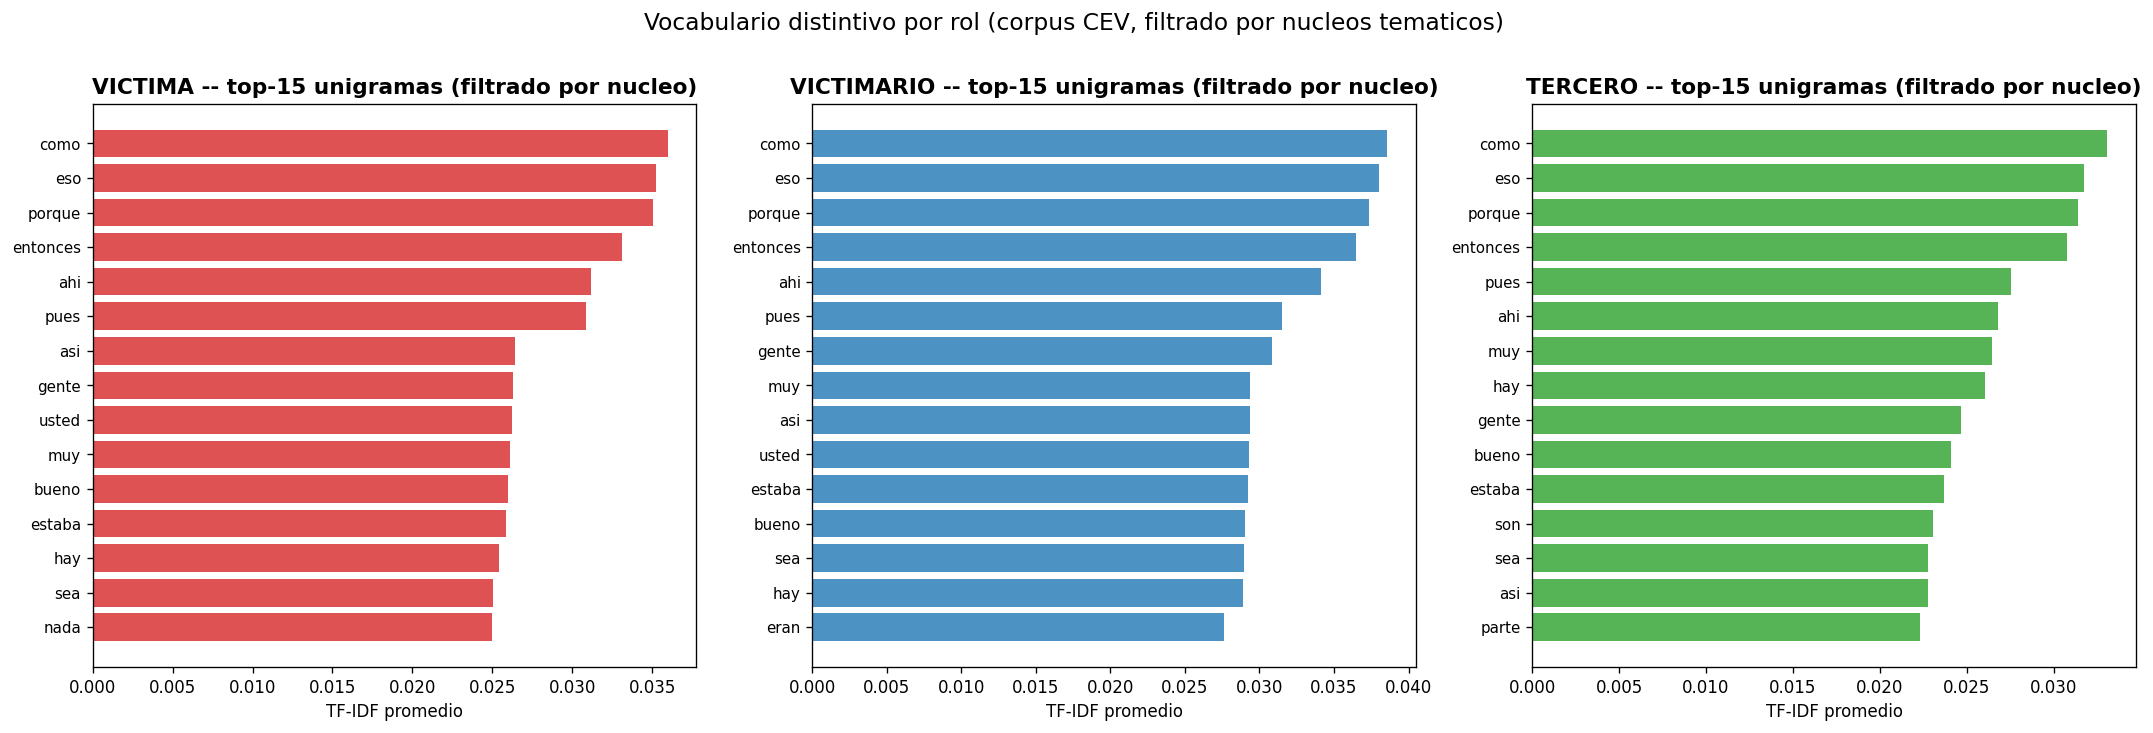

Grafico guardado: ..\Evaluacion\resultados\tfidf_por_rol.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
COLORES = {'victima':'#d62728', 'victimario':'#1f77b4', 'tercero':'#2ca02c'}

for ax, rol in zip(axes, ['victima','victimario','tercero']):
    if rol not in tfidf.get(1, {}) or not tfidf[1][rol]:
        ax.set_title(f'{rol} -- sin datos')
        continue
    top = tfidf[1][rol][:15]
    ngs = [t[0] for t in top][::-1]
    scs = [t[1] for t in top][::-1]
    ax.barh(ngs, scs, color=COLORES[rol], alpha=0.8)
    ax.set_title(f'{rol.upper()} -- top-15 unigramas (filtrado por nucleo)', fontsize=13, fontweight='bold')
    ax.set_xlabel('TF-IDF promedio')
    ax.tick_params(axis='y', labelsize=9)

plt.suptitle('Vocabulario distintivo por rol (corpus CEV, filtrado por nucleos tematicos)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(CARPETA_OUT / 'tfidf_por_rol.png', bbox_inches='tight')
plt.show()
print('Grafico guardado:', CARPETA_OUT / 'tfidf_por_rol.png')

In [12]:
ESPERADAS = {
    'victima'    : ['desplazamiento','masacre','miedo','muerte','amenaza','coca','cultivo'],
    'victimario' : ['operacion','combate','guerrilla','patrulla','comando','frente','escuadra'],
    'tercero'    : ['comunidad','denuncia','derechos','organizacion','informe','estado','politica'],
}
print('Verificacion palabras clave en top-500 TF-IDF (n=1):')
for rol, palabras in ESPERADAS.items():
    if rol not in tfidf.get(1, {}):
        print(f'  {rol}: sin datos')
        continue
    top500   = {ng for ng, _ in tfidf[1][rol][:500]}
    halladas = [p for p in palabras if p in top500]
    print(f'  {rol:12s}: {len(halladas)}/{len(palabras)} encontradas -> {halladas}')

Verificacion palabras clave en top-500 TF-IDF (n=1):
  victima     : 4/7 encontradas -> ['desplazamiento', 'miedo', 'muerte', 'coca']
  victimario  : 4/7 encontradas -> ['combate', 'guerrilla', 'frente', 'escuadra']
  tercero     : 6/7 encontradas -> ['comunidad', 'derechos', 'organizacion', 'informe', 'estado', 'politica']
